**Import dependencies**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
from pathlib import Path

**Check prediction quality**

In [7]:
# Load data
data = pd.read_csv("test_log_kernel.csv")

tau_ext = data.filter(like="tau_ext_").to_numpy() # shape (T, 7)
predictions = data.filter(like="friction_pred_").to_numpy() # shape (T, 7)

print("tau_ext shape:", tau_ext.shape)
print("predictions shape:", predictions.shape)

tau_ext shape: (25553, 7)
predictions shape: (25553, 7)


**Plot predictions**

Joint 0: RMSE = 0.1235 Nm
Joint 1: RMSE = 0.3560 Nm
Joint 2: RMSE = 0.1386 Nm
Joint 3: RMSE = 0.0817 Nm
Joint 4: RMSE = 0.0351 Nm
Joint 5: RMSE = 0.0723 Nm
Joint 6: RMSE = 0.0056 Nm


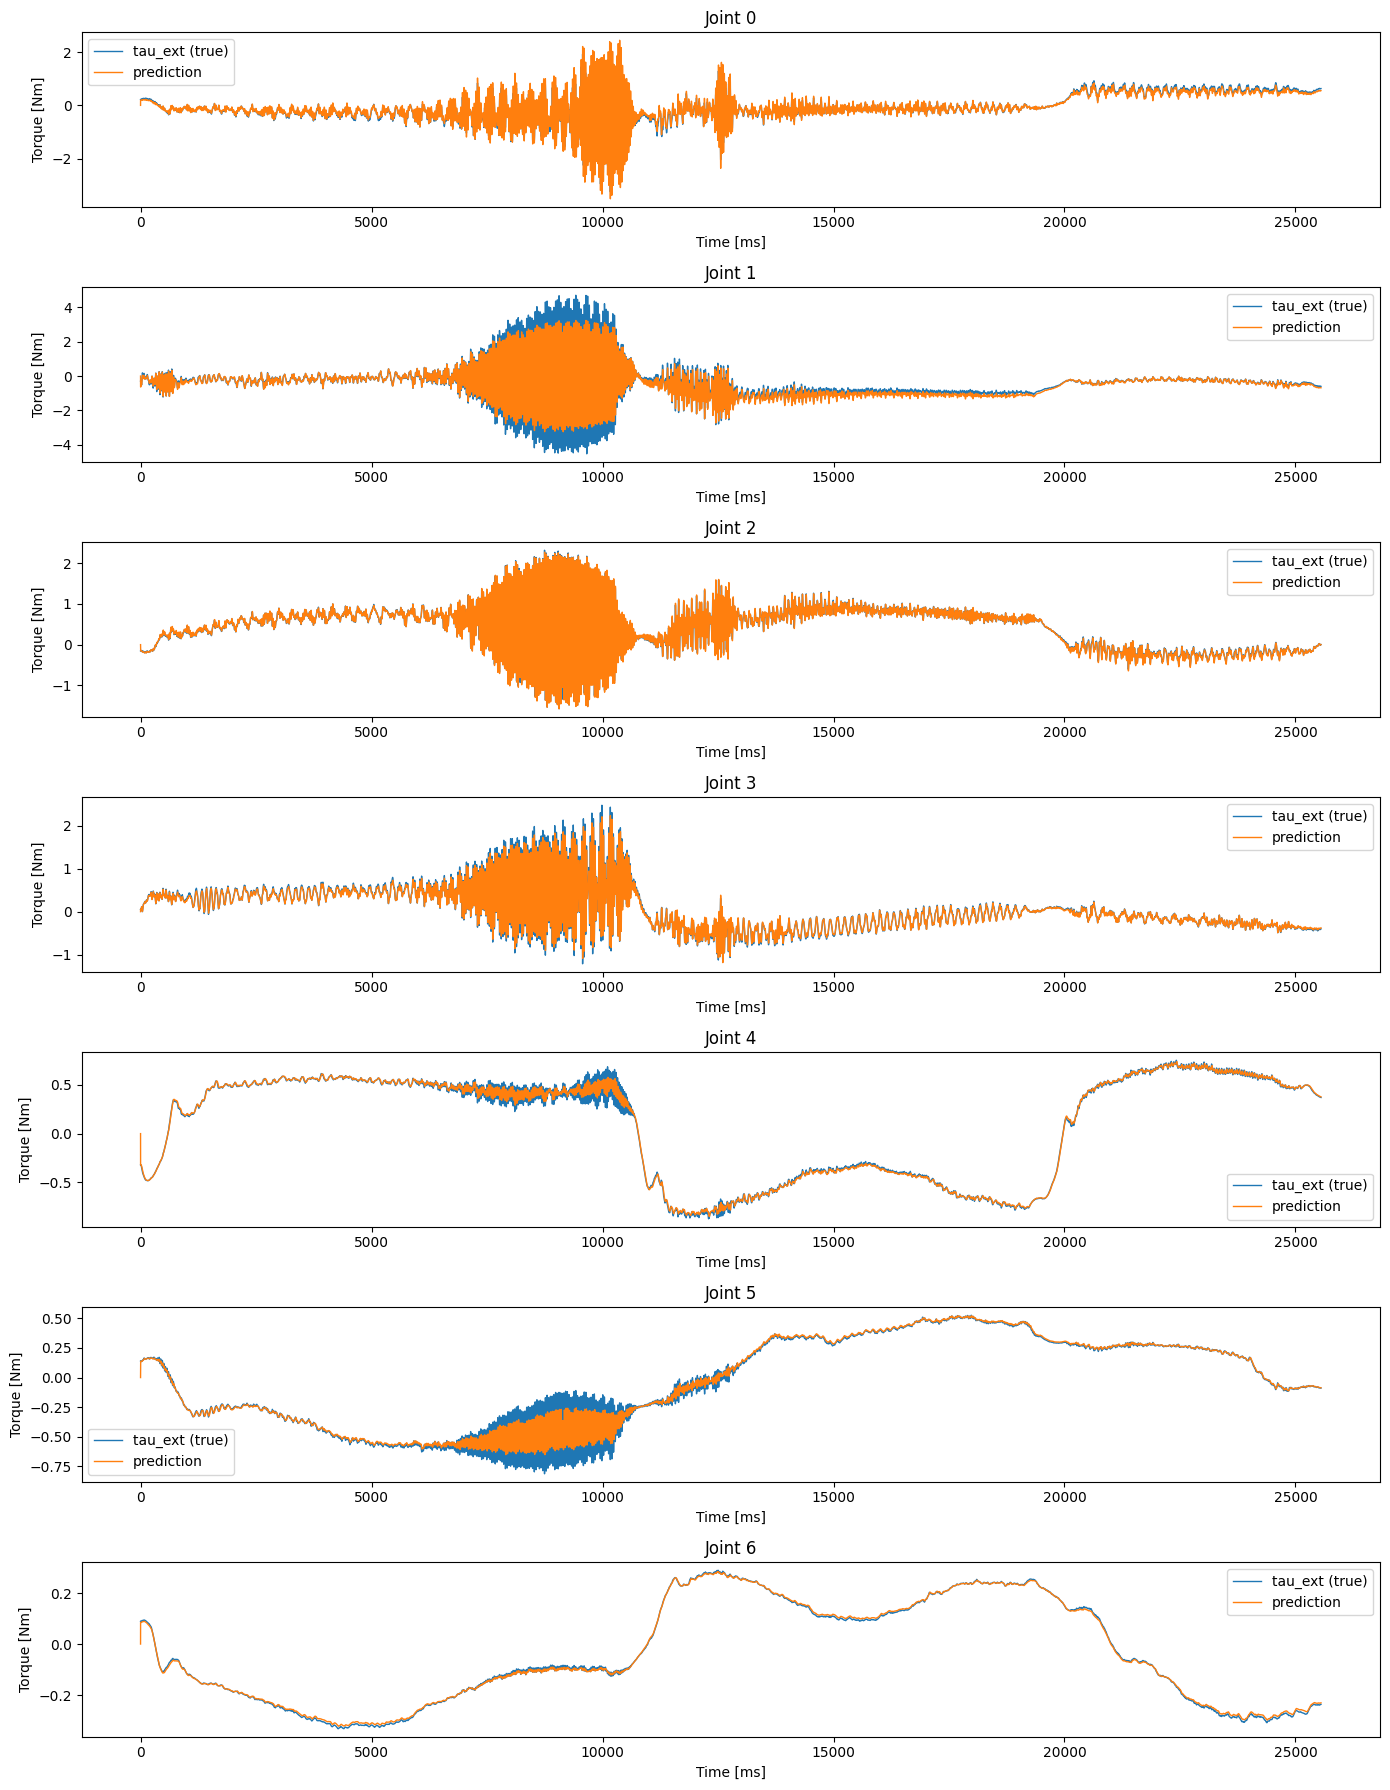

In [8]:
num_joints = tau_ext.shape[1]

plt.figure(figsize=(14, 18))

for i in range(num_joints):

    err = tau_ext[:, i] - predictions[:, i]
    rmse = np.sqrt(np.mean(err**2))
    print(f"Joint {i}: RMSE = {rmse:.4f} Nm")
    
    plt.subplot(num_joints, 1, i + 1)
    plt.plot(tau_ext[:, i], label="tau_ext (true)", linewidth=1.0)
    plt.plot(predictions[:, i], label="prediction", linewidth=1.0)
    plt.title(f"Joint {i}")
    plt.xlabel("Time [ms]")
    plt.ylabel("Torque [Nm]")
    plt.legend()

plt.tight_layout()
plt.show()

**Load residuals**

In [9]:
# Load data
data = pd.read_csv("test_log_kernel.csv")

residuals = data.filter(like="residual_").to_numpy()[1:, :] # shape (T, 7)

print("residuals_full shape:", residuals.shape)

residuals_full shape: (25552, 7)


**PLot residuals vs tau_ext**

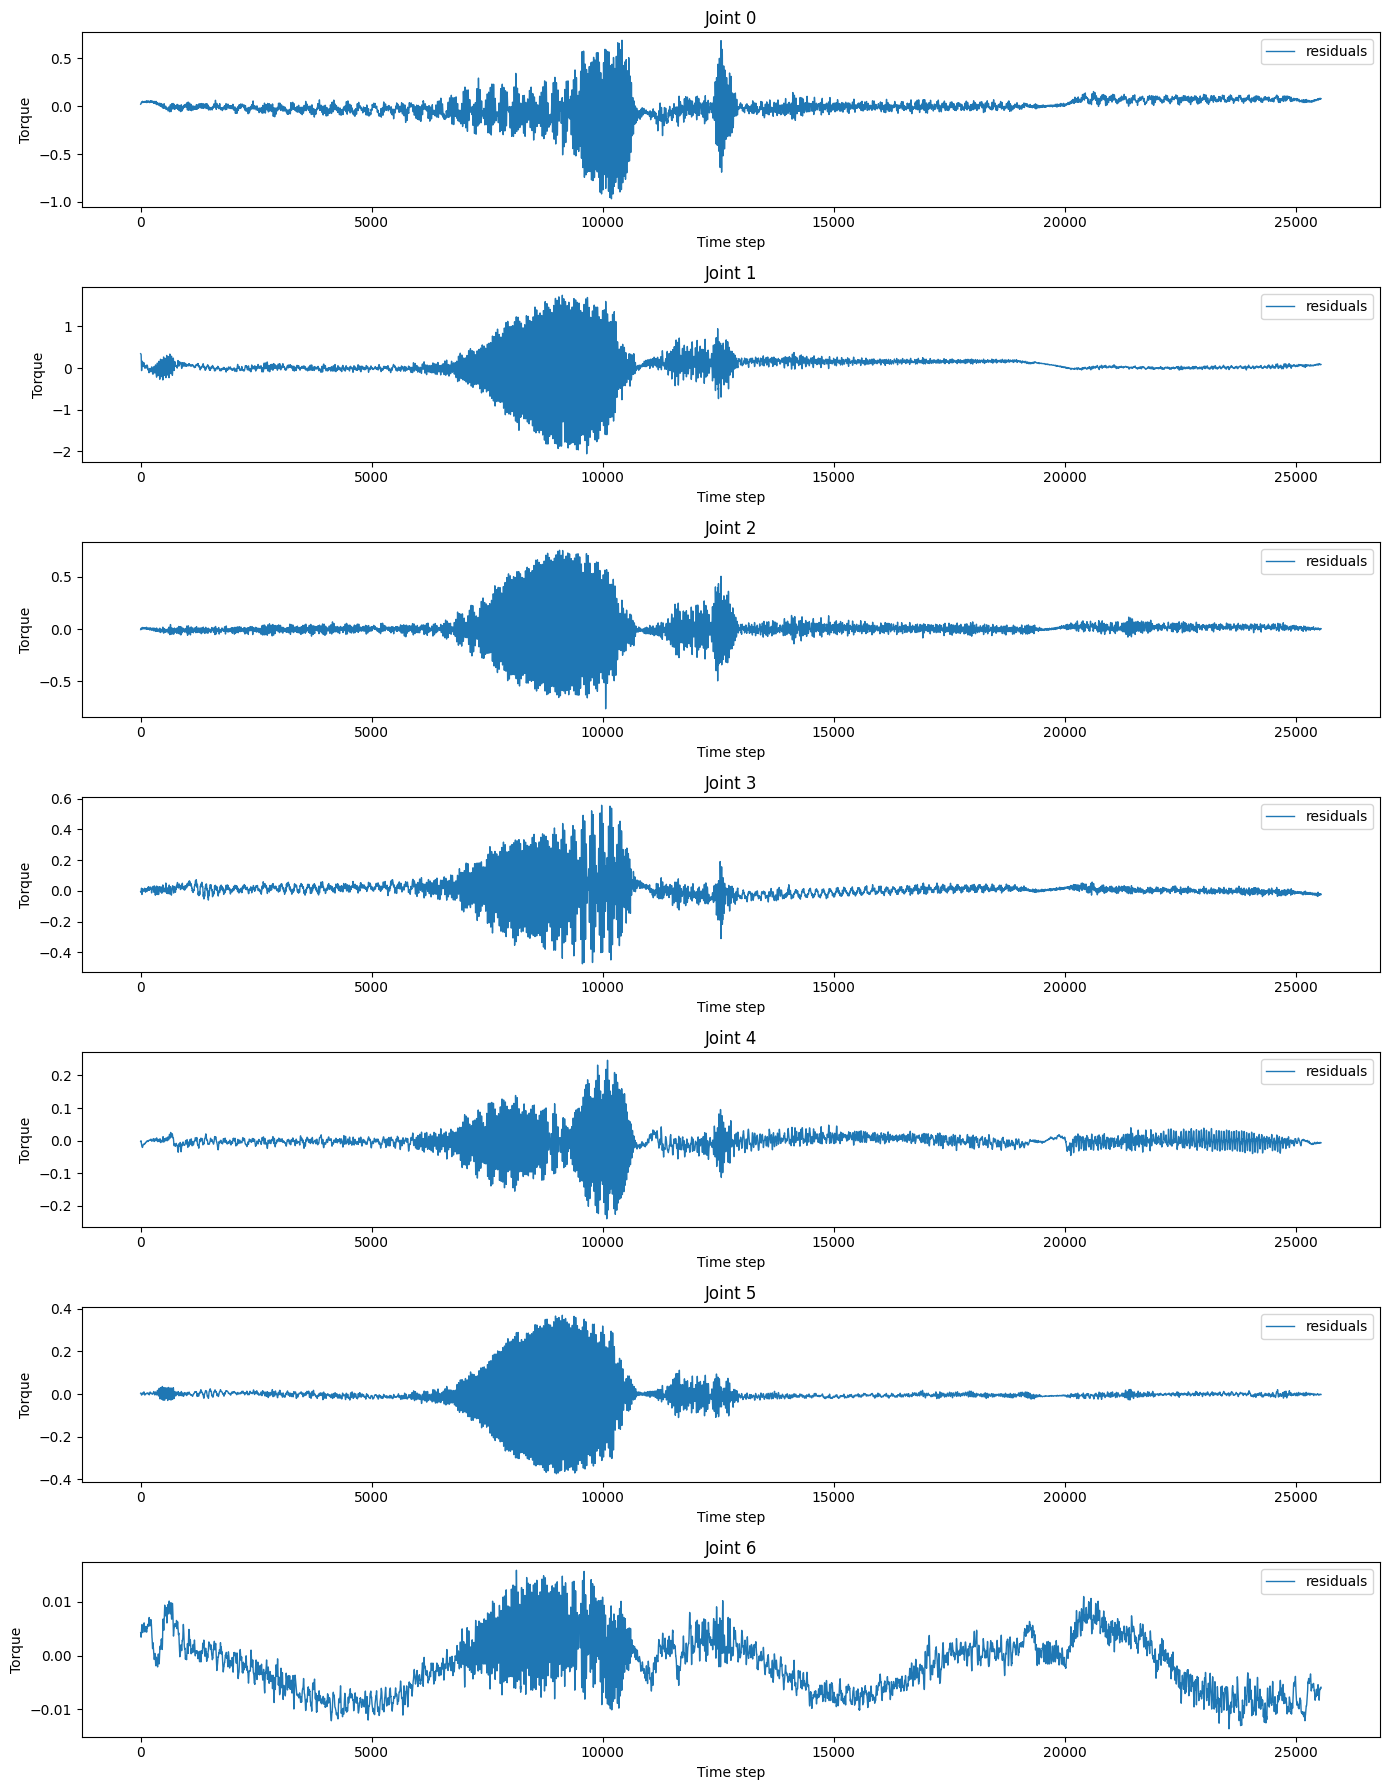

In [10]:
num_joints = residuals.shape[1]

plt.figure(figsize=(14, 18))

for i in range(num_joints):
    plt.subplot(num_joints, 1, i + 1)
    plt.plot(residuals[:, i], label="residuals", linewidth=1.0)
    plt.title(f"Joint {i}")
    plt.xlabel("Time step")
    plt.ylabel("Torque")
    plt.legend()

plt.tight_layout()
plt.show()

**Load joint positions**

In [15]:
# Load data
data = pd.read_csv("test_log.csv")
kernel_data = pd.read_csv("test_log_kernel.csv")

q_des = data.filter(like="q_des_").to_numpy()[1:25553, :] # shape (T, 7)
q_curr = data.filter(like="q_curr_").to_numpy()[1:25553, :]# shape (T, 7)
q_curr_kernel = kernel_data.filter(like="q_curr_").to_numpy()[1:, :] # shape (T, 7)

print("q_des shape:", q_des.shape)
print("q_curr shape:", q_curr.shape)
print("q_curr_kernel shape:", q_curr_kernel.shape)

q_des shape: (25552, 7)
q_curr shape: (25552, 7)
q_curr_kernel shape: (25552, 7)


**Plot tracking quality**

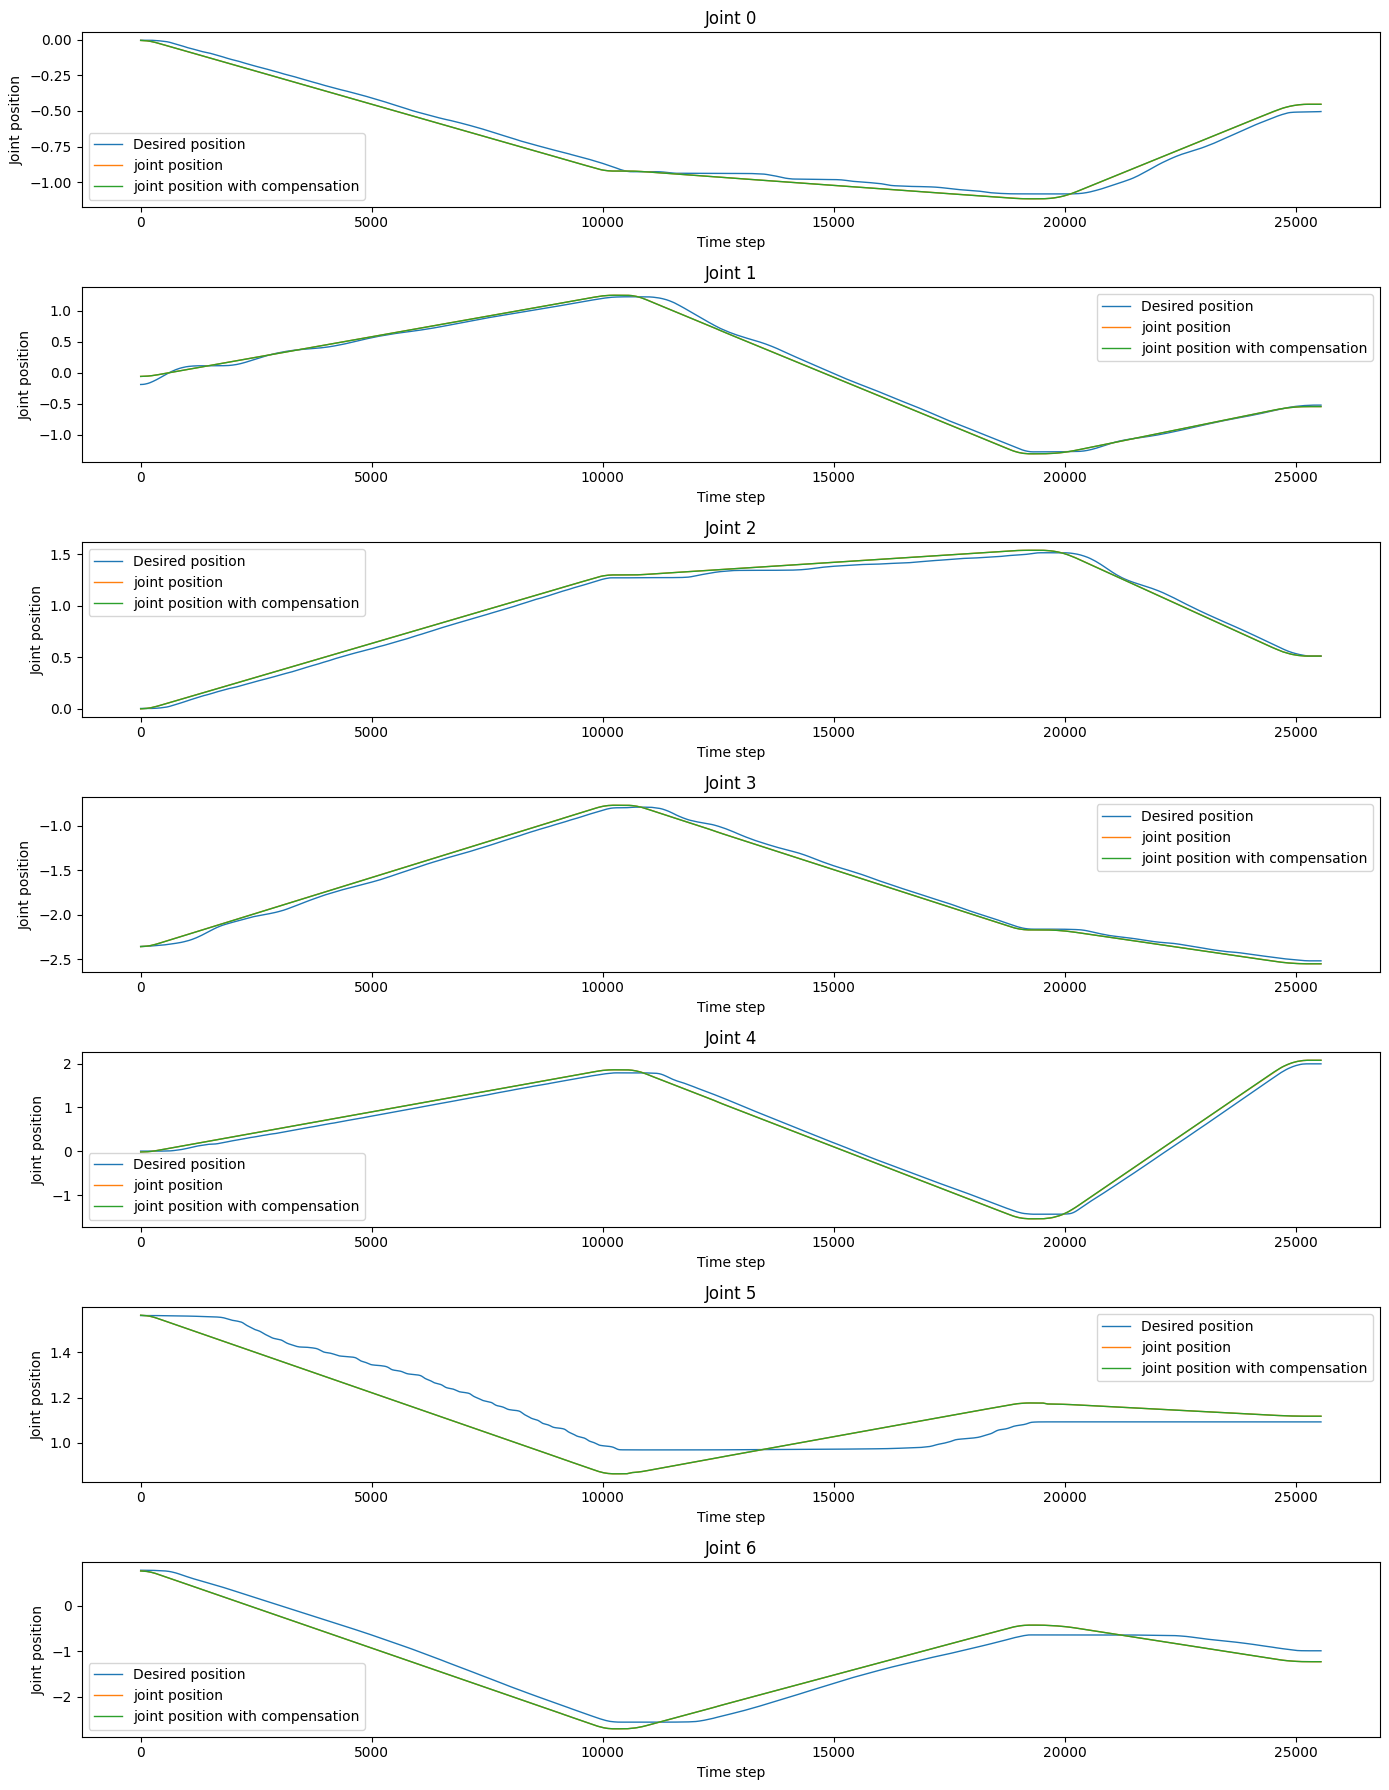

Joint 0: RMSE no-ff = 0.03837, with-ff = 0.03848
Joint 1: RMSE no-ff = 0.04864, with-ff = 0.04916
Joint 2: RMSE no-ff = 0.04028, with-ff = 0.04039
Joint 3: RMSE no-ff = 0.04093, with-ff = 0.04104
Joint 4: RMSE no-ff = 0.09970, with-ff = 0.10103
Joint 5: RMSE no-ff = 0.09204, with-ff = 0.09198
Joint 6: RMSE no-ff = 0.20738, with-ff = 0.20740


In [16]:
num_joints = q_des.shape[1]

plt.figure(figsize=(14, 18))

for i in range(num_joints):
    plt.subplot(num_joints, 1, i + 1)
    plt.plot(q_des[:, i], label="Desired position", linewidth=1.0)
    plt.plot(q_curr[:, i], label="joint position", linewidth=1.0)
    plt.plot(q_curr_kernel[:, i], label="joint position with compensation", linewidth=1.0)
    plt.title(f"Joint {i}")
    plt.xlabel("Time step")
    plt.ylabel("Joint position")
    plt.legend()

plt.tight_layout()
plt.show()

def rmse(a, b):
    err = a - b
    return np.sqrt(np.mean(err**2))

for j in range(num_joints):
    rmse_noff = rmse(q_curr[:, j], q_des[:, j])
    rmse_ff = rmse(q_curr_kernel[:, j],   q_des[:, j])
    print(f"Joint {j}: RMSE no-ff = {rmse_noff:.5f}, with-ff = {rmse_ff:.5f}")
